In [ ]:
# NOTEBOOK 3 — 03_explainability_and_ablation.ipynb

# Objetivo: análises complementares para artigo e aprofundamento.

In [ ]:
# Fica responsável por:

# SHAP
# Experimento sem variáveis territoriais
# Calibração
# Tuning com Optuna
# Análises complementares para artigo

# Notebook 3 entrega

# Explicabilidade com SHAP
# Ablação sem territorialidade
# Calibração
# Tuning com Optuna
# Material extra para artigo

In [48]:
# ============================================================
# CÉLULA 1 — IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool

RANDOM_STATE = 42

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [49]:
# ============================================================
# CÉLULA 2 — CARREGAR ARTEFATOS
# ============================================================

INPUT_DIR_1 = "outputs/notebook1"
INPUT_DIR_2 = "outputs/notebook2"
OUTPUT_DIR = "outputs/notebook3"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train_clipped = joblib.load(os.path.join(INPUT_DIR_1, "X_train_clipped.pkl"))
X_val_clipped = joblib.load(os.path.join(INPUT_DIR_1, "X_val_clipped.pkl"))
X_test_clipped = joblib.load(os.path.join(INPUT_DIR_1, "X_test_clipped.pkl"))

y_train = joblib.load(os.path.join(INPUT_DIR_1, "y_train.pkl"))
y_val = joblib.load(os.path.join(INPUT_DIR_1, "y_val.pkl"))
y_test = joblib.load(os.path.join(INPUT_DIR_1, "y_test.pkl"))

X_trainval_prepared = joblib.load(os.path.join(INPUT_DIR_1, "X_trainval_prepared.pkl"))
X_test_prepared = joblib.load(os.path.join(INPUT_DIR_1, "X_test_prepared.pkl"))
y_trainval = joblib.load(os.path.join(INPUT_DIR_1, "y_trainval.pkl"))

rare_maps = joblib.load(os.path.join(INPUT_DIR_1, "rare_maps.pkl"))
clip_bounds = joblib.load(os.path.join(INPUT_DIR_1, "clip_bounds.pkl"))
scale_pos_weight = joblib.load(os.path.join(INPUT_DIR_1, "scale_pos_weight.pkl"))

final_model = joblib.load(os.path.join(INPUT_DIR_2, "final_model.pkl"))

with open(os.path.join(INPUT_DIR_2, "best_model_summary.json"), "r", encoding="utf-8") as f:
    best_model_summary = json.load(f)

best_model_name = best_model_summary["best_model_name"]
best_threshold = best_model_summary["best_threshold"]

print("Melhor modelo carregado:", best_model_name)
print("Threshold original:", best_threshold)

# Melhor modelo carregado: LightGBM
# Threshold original: 0.09

Melhor modelo carregado: LightGBM
Threshold original: 0.09


In [50]:
# ============================================================
# CÉLULA 3 — FUNÇÕES AUXILIARES
# ============================================================

def evaluate_binary_model(y_true, y_proba, threshold, model_name="modelo", dataset_name="dataset"):
    y_pred = (y_proba >= threshold).astype(int)

    results = {
        "dataset": dataset_name,
        "modelo": model_name,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_proba),
        "auc_pr": average_precision_score(y_true, y_proba)
    }

    return results, y_pred


def find_best_threshold(y_true, y_proba, start=0.05, end=0.95, step=0.01):
    thresholds = np.arange(start, end + step, step)
    rows = []

    for thr in thresholds:
        pred = (y_proba >= thr).astype(int)
        rows.append({
            "threshold": thr,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0)
        })

    thr_df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
    best_threshold = float(thr_df.loc[0, "threshold"])
    return best_threshold, thr_df


def prepare_catboost_input(df, reference_columns=None):
    df = df.copy()

    if reference_columns is not None:
        missing_cols = [col for col in reference_columns if col not in df.columns]
        for col in missing_cols:
            df[col] = np.nan
        df = df[reference_columns]

    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    for col in cat_cols:
        df[col] = df[col].astype("object")
        df[col] = df[col].fillna("__MISSING__")
        df[col] = df[col].astype(str)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

        if df[col].isna().any():
            med = df[col].median()
            if pd.isna(med):
                med = 0.0
            df[col] = df[col].fillna(med)

    return df, cat_cols

In [51]:
# ============================================================
# CÉLULA 4 — PREPARAÇÃO ROBUSTA PARA LIGHTGBM
# ============================================================

def prepare_lgbm_input(df, reference_columns=None):
    df = df.copy()

    if reference_columns is not None:
        missing_cols = [col for col in reference_columns if col not in df.columns]
        for col in missing_cols:
            df[col] = np.nan
        df = df[reference_columns]

    for col in df.columns:
        if pd.api.types.is_bool_dtype(df[col]):
            df[col] = df[col].astype(int)

        elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
            df[col] = (
                df[col]
                .astype("object")
                .where(pd.notna(df[col]), "__MISSING__")
            )
            df[col] = pd.Categorical(df[col]).codes

        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)

            if df[col].isna().any():
                med = df[col].median()
                if pd.isna(med):
                    med = 0.0
                df[col] = df[col].fillna(med)

    return df

In [52]:
# ============================================================
# CÉLULA 5 — RECRIAR BASE COMUM FINAL
# ============================================================

drop_high_card_text = [
    "d.nom_centro_assist_fam",
    "d.nom_estab_assist_saude_fam",
    "p.nom_escola_memb",
    "p.nom_ibge_munic_nasc_pessoa",
    "p.nom_munic_certid_pessoa",
    "p.nom_munic_escola_memb",
]

common_drop_cols = [c for c in drop_high_card_text if c in X_trainval_prepared.columns]

X_full_common = X_trainval_prepared.drop(columns=common_drop_cols, errors="ignore").copy()
X_test_final_common = X_test_prepared.drop(columns=common_drop_cols, errors="ignore").copy()

X_test_final_common = X_test_final_common.reindex(columns=X_full_common.columns).copy()

print("X_full_common:", X_full_common.shape)
print("X_test_final_common:", X_test_final_common.shape)
print("Colunas removidas:", common_drop_cols)

# X_full_common: (449323, 255)
# X_test_final_common: (431036, 255)
# Colunas removidas: ['d.nom_centro_assist_fam', 'd.nom_estab_assist_saude_fam', 'p.nom_escola_memb', 'p.nom_ibge_munic_nasc_pessoa', 'p.nom_munic_certid_pessoa', 'p.nom_munic_escola_memb']

X_full_common: (449323, 255)
X_test_final_common: (431036, 255)
Colunas removidas: ['d.nom_centro_assist_fam', 'd.nom_estab_assist_saude_fam', 'p.nom_escola_memb', 'p.nom_ibge_munic_nasc_pessoa', 'p.nom_munic_certid_pessoa', 'p.nom_munic_escola_memb']


In [53]:
# ============================================================
# CÉLULA 6 — COLUNAS DE REFERÊNCIA
# ============================================================

if best_model_name == "CatBoost":
    X_reference_cat, reference_cat_cols = prepare_catboost_input(X_full_common)
    final_train_columns = X_reference_cat.columns.tolist()
else:
    final_train_columns = X_full_common.columns.tolist()

print("Número de colunas de referência:", len(final_train_columns))
print("Exemplo de colunas:", final_train_columns[:10])

# Número de colunas de referência: 255
# Exemplo de colunas: ['d.cd_ibge', 'd.cod_abaste_agua_domic_fam', 'd.cod_agua_canalizada_fam', 'd.cod_banheiro_domic_fam', 'd.cod_calcamento_domic_fam', 'd.cod_centro_assist_fam', 'd.cod_cta_energ_unid_consum_fam', 'd.cod_destino_lixo_domic_fam', 'd.cod_eas_fam', 'd.cod_escoa_sanitario_domic_fam']

Número de colunas de referência: 255
Exemplo de colunas: ['d.cd_ibge', 'd.cod_abaste_agua_domic_fam', 'd.cod_agua_canalizada_fam', 'd.cod_banheiro_domic_fam', 'd.cod_calcamento_domic_fam', 'd.cod_centro_assist_fam', 'd.cod_cta_energ_unid_consum_fam', 'd.cod_destino_lixo_domic_fam', 'd.cod_eas_fam', 'd.cod_escoa_sanitario_domic_fam']


In [54]:
print("Colunas no treino final:", len(final_train_columns))
print("Colunas no teste final comum:", X_test_final_common.shape[1])
print("Colunas faltando no teste comum:", set(final_train_columns) - set(X_test_final_common.columns))
print("Colunas extras no teste comum:", set(X_test_final_common.columns) - set(final_train_columns))

# Colunas no treino final: 255
# Colunas no teste final comum: 255
# Colunas faltando no teste comum: set()
# Colunas extras no teste comum: set()

Colunas no treino final: 255
Colunas no teste final comum: 255
Colunas faltando no teste comum: set()
Colunas extras no teste comum: set()


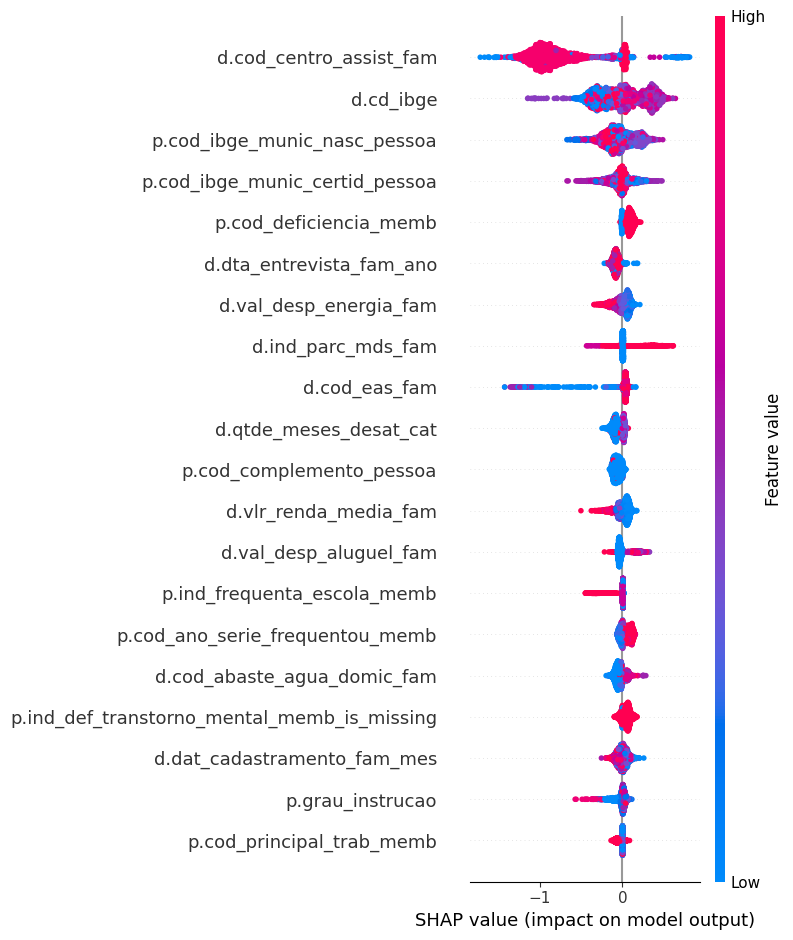

,feature,mean_abs_shap
0,d.cod_centro_assist_fam,0.770986
1,d.cd_ibge,0.237630
2,p.cod_ibge_munic_nasc_pessoa,0.145973
3,p.cod_ibge_munic_certid_pessoa,0.096722
4,p.cod_deficiencia_memb,0.085900
5,d.dta_entrevista_fam_ano,0.079920
6,d.val_desp_energia_fam,0.070217
7,d.ind_parc_mds_fam,0.066683
8,d.cod_eas_fam,0.065735
9,d.qtde_meses_desat_cat,0.064243


In [ ]:
# ============================================================
# CÉLULA 7 — SHAP (ROBUSTO E CONSISTENTE)
# ============================================================

X_val_common = X_val_clipped.drop(columns=common_drop_cols, errors="ignore").copy()
X_val_common = X_val_common.reindex(columns=final_train_columns).copy()

sample_size = min(3000, len(X_val_common))
X_val_sample_raw = X_val_common.sample(sample_size, random_state=RANDOM_STATE).copy()

if best_model_name == "CatBoost":
    X_val_sample, cat_cols_shap = prepare_catboost_input(
        X_val_sample_raw,
        reference_columns=final_train_columns
    )
    cat_idx_shap = [X_val_sample.columns.get_loc(c) for c in cat_cols_shap]

    pool_shap = Pool(
        X_val_sample,
        cat_features=cat_idx_shap
    )

    shap_raw = final_model.get_feature_importance(
        pool_shap,
        type="ShapValues"
    )

    # última coluna = expected value
    shap_values_to_plot = shap_raw[:, :-1]

else:
    X_val_sample = prepare_lgbm_input(
        X_val_sample_raw,
        reference_columns=final_train_columns
    )

    # garantir matriz puramente numérica
    X_val_sample_num = X_val_sample.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    X_val_sample_num = X_val_sample_num.astype(np.float32)

    # usar o booster do LightGBM diretamente
    shap_raw = final_model.booster_.predict(
        X_val_sample_num.values,
        pred_contrib=True
    )

    # última coluna = expected value
    shap_values_to_plot = shap_raw[:, :-1]

shap_values_to_plot = np.asarray(shap_values_to_plot)

assert shap_values_to_plot.shape[1] == X_val_sample.shape[1], (
    f"SHAP shape {shap_values_to_plot.shape} incompatível com X_val_sample {X_val_sample.shape}"
)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_to_plot,
    X_val_sample,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_summary_plot.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "shap_summary_plot.pdf"), format="pdf", bbox_inches="tight")
plt.show()

shap_importance_base = (
    pd.DataFrame({
        "feature": X_val_sample.columns,
        "mean_abs_shap": np.abs(shap_values_to_plot).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_base.head(20))

# feature	mean_abs_shap
# 0	d.cod_centro_assist_fam	0.770986
# 1	d.cd_ibge	0.237630
# 2	p.cod_ibge_munic_nasc_pessoa	0.145973
# 3	p.cod_ibge_munic_certid_pessoa	0.096722
# 4	p.cod_deficiencia_memb	0.085900
# 5	d.dta_entrevista_fam_ano	0.079920
# 6	d.val_desp_energia_fam	0.070217
# 7	d.ind_parc_mds_fam	0.066683
# 8	d.cod_eas_fam	0.065735
# 9	d.qtde_meses_desat_cat	0.064243
# 10	p.cod_complemento_pessoa	0.062715
# 11	d.vlr_renda_media_fam	0.061859
# 12	d.val_desp_aluguel_fam	0.058062
# 13	p.ind_frequenta_escola_memb	0.056245
# 14	p.cod_ano_serie_frequentou_memb	0.055459
# 15	d.cod_abaste_agua_domic_fam	0.052647
# 16	p.ind_def_transtorno_mental_memb_is_missing	0.052527
# 17	d.dat_cadastramento_fam_mes	0.046375
# 18	p.grau_instrucao	0.045101
# 19	p.cod_principal_trab_memb	0.042381


A análise SHAP revela que o modelo é fortemente influenciado por identificadores geográficos e administrativos, como códigos de municípios e identificadores de centros de assistência. Embora essas variáveis ​​capturem a heterogeneidade espacial relevante, elas também podem introduzir vieses relacionados a padrões específicos de cada local, potencialmente limitando a generalização do modelo.

Variáveis ​​socioeconômicas, incluindo renda familiar, despesas com energia e custos de moradia, também contribuem significativamente para as previsões do modelo, alinhando-se com determinantes já estabelecidos da insegurança alimentar. No entanto, sua importância relativa é menor em comparação com as variáveis ​​geográficas, sugerindo que o modelo depende parcialmente da memorização espacial.

Esses resultados destacam a importância de avaliar cuidadosamente a seleção de variáveis ​​para equilibrar o desempenho preditivo e a interpretabilidade.

Top 20 features by mean(|SHAP|):
                                    feature  mean_abs_shap
                    d.cod_centro_assist_fam       0.770986
                                  d.cd_ibge       0.237630
               p.cod_ibge_munic_nasc_pessoa       0.145973
             p.cod_ibge_munic_certid_pessoa       0.096722
                     p.cod_deficiencia_memb       0.085900
                   d.dta_entrevista_fam_ano       0.079920
                     d.val_desp_energia_fam       0.070217
                         d.ind_parc_mds_fam       0.066683
                              d.cod_eas_fam       0.065735
                     d.qtde_meses_desat_cat       0.064243
                   p.cod_complemento_pessoa       0.062715
                      d.vlr_renda_media_fam       0.061859
                     d.val_desp_aluguel_fam       0.058062
                p.ind_frequenta_escola_memb       0.056245
            p.cod_ano_serie_frequentou_memb       0.055459
                d.cod_a

,group,mean_abs_shap,percentage
0,Territorial,1.463272,45.820703
1,Socioeconomic,0.711119,22.267895
2,Temporal,0.559446,17.518422
3,Other,0.459636,14.392979
4,Administrative,0.000000,0.000000


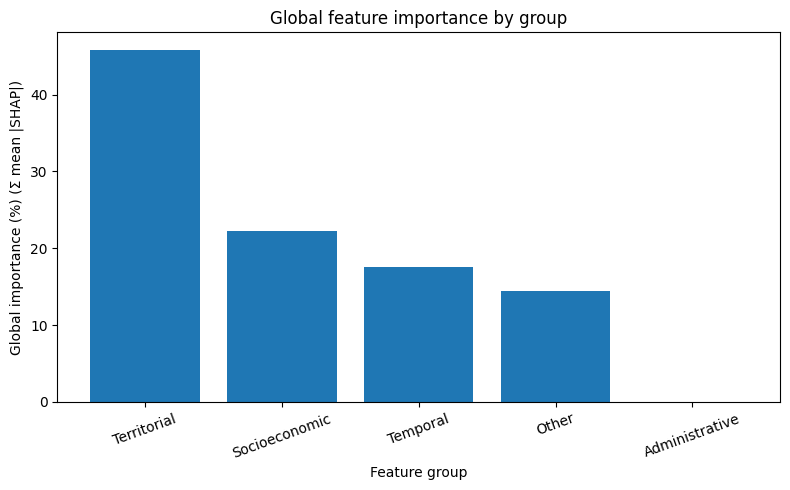

In [ ]:
# ============================================================
# CÉLULA 8 — SHAP AGRUPADO POR TIPO DE VARIÁVEL
# ============================================================

X_explain = X_val_sample.copy()
shap_values = shap_values_to_plot.copy()

# Mean absolute SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)

df_shap_importance = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top 20 features by mean(|SHAP|):")
print(df_shap_importance.head(20).to_string(index=False))

# ------------------------------------------------------------
# Manual mapping (if needed)
# ------------------------------------------------------------
manual_group_map = {
    "d.nom_estab_assist_saude_fam": "Territorial",
    "d.dat_ult_atual_fam": "Temporal",
    "d.qtd_pessoas_domic_fam": "Socioeconomic",
    "d.vlr_renda_media_fam": "Socioeconomic",
    "d.vlr_renda_total_fam": "Socioeconomic",
    "d.val_desp_alimentacao_fam": "Socioeconomic",
    "d.val_desp_agua_esgoto_fam": "Socioeconomic",
    "d.val_desp_energia_fam": "Socioeconomic",
    "d.val_desp_aluguel_fam": "Socioeconomic",
    "d.cod_ibge_fam": "Territorial",
    "p.cod_ibge_munic_nasc_pessoa": "Territorial",
    "d.cod_eas_fam": "Territorial",
    "d.cod_material_piso_fam": "Socioeconomic",
    "d.cod_calcamento_domic_fam": "Socioeconomic",
    "p.cod_curso_frequentou_pessoa_memb": "Socioeconomic",
    "d.vlr_fam_dia_semana": "Administrative",
    "d.cod_abaste_agua_domic_fam": "Socioeconomic"
}

# ------------------------------------------------------------
# Keyword-based grouping
# ------------------------------------------------------------
territorial_keywords = [
    "ibge", "munic", "uf", "bairro", "territ", "local",
    "centro_assist", "eas", "estab_assist", "escola",
    "nom_munic", "cod_munic", "cd_ibge"
]

temporal_keywords = [
    "dat_", "data_", "dta_", "_mes", "_ano", "_dia",
    "_semana", "cadastro", "atual", "entrevista"
]

administrative_keywords = [
    "cadastro", "entrevista", "responsavel", "formulario",
    "atend", "posto", "gestao", "controle", "atualizacao"
]

socioeconomic_keywords = [
    "renda", "rfpc", "desp", "qtd_", "comodo", "domic",
    "agua", "energia", "aluguel", "material", "curso",
    "escolar", "trabalho", "ocup", "idade"
]

def assign_group(feature_name):
    if feature_name in manual_group_map:
        return manual_group_map[feature_name]

    f = feature_name.lower()

    if any(k in f for k in territorial_keywords):
        return "Territorial"
    if any(k in f for k in temporal_keywords):
        return "Temporal"
    if any(k in f for k in administrative_keywords):
        return "Administrative"
    if any(k in f for k in socioeconomic_keywords):
        return "Socioeconomic"
    return "Other"

df_shap_importance["group"] = df_shap_importance["feature"].apply(assign_group)

# ------------------------------------------------------------
# Aggregate importance by group
# ------------------------------------------------------------
group_importance = (
    df_shap_importance
    .groupby("group", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

group_importance["percentage"] = (
    100 * group_importance["mean_abs_shap"] / group_importance["mean_abs_shap"].sum()
)

display(group_importance)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(group_importance["group"], group_importance["percentage"])
plt.ylabel("Global importance (%) (Σ mean |SHAP|)")
plt.xlabel("Feature group")
plt.title("Global feature importance by group")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_grouped_importance.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "shap_grouped_importance.pdf"), format="pdf", bbox_inches="tight")
plt.show()

# Top 20 variáveis por mean(|SHAP|):
#                                     feature  mean_abs_shap
#                     d.cod_centro_assist_fam       0.770986
#                                   d.cd_ibge       0.237630
#                p.cod_ibge_munic_nasc_pessoa       0.145973
#              p.cod_ibge_munic_certid_pessoa       0.096722
#                      p.cod_deficiencia_memb       0.085900
#                    d.dta_entrevista_fam_ano       0.079920
#                      d.val_desp_energia_fam       0.070217
#                          d.ind_parc_mds_fam       0.066683
#                               d.cod_eas_fam       0.065735
#                      d.qtde_meses_desat_cat       0.064243
#                    p.cod_complemento_pessoa       0.062715
#                       d.vlr_renda_media_fam       0.061859
#                      d.val_desp_aluguel_fam       0.058062
#                 p.ind_frequenta_escola_memb       0.056245
#             p.cod_ano_serie_frequentou_memb       0.055459
#                 d.cod_abaste_agua_domic_fam       0.052647
# p.ind_def_transtorno_mental_memb_is_missing       0.052527
#                 d.dat_cadastramento_fam_mes       0.046375
#                            p.grau_instrucao       0.045101
#                   p.cod_principal_trab_memb       0.042381

A análise SHAP agrupada revela que as variáveis ​​territoriais respondem por aproximadamente 45,8% da importância preditiva do modelo, indicando uma forte dependência espacial nos padrões de insegurança alimentar. Isso sugere que a localização geográfica desempenha um papel central na determinação da vulnerabilidade, provavelmente refletindo desigualdades estruturais entre os municípios.

As variáveis ​​socioeconômicas contribuem com 22,3% da importância do modelo, incluindo renda familiar, gastos com energia e custos de moradia, alinhando-se com determinantes já estabelecidos na literatura. As variáveis ​​temporais respondem por 17,5%, indicando que a insegurança alimentar também apresenta dinâmicas temporais, possivelmente associadas a mudanças de políticas públicas ou flutuações econômicas.

Esses resultados destacam que o modelo captura uma estrutura multidimensional de vulnerabilidade, combinando sinais espaciais, econômicos e temporais. No entanto, a forte dependência de variáveis ​​territoriais levanta potenciais preocupações quanto à generalização do modelo e ao viés espacial, justificando investigações adicionais.

## Métodos

Para interpretar as previsões do modelo, empregamos o SHAP (SHapley Additive exPlanations), que fornece uma estrutura unificada para medir as contribuições das variáveis ​​com base na teoria dos jogos cooperativos.

Para cada variável, calculamos o valor médio absoluto do SHAP em todas as amostras de validação, o que representa a contribuição média de cada variável para a saída do modelo.

Além disso, agrupamos as variáveis ​​em quatro categorias semânticas: Territorial, Socioeconômica, Temporal e Administrativa. Esse agrupamento foi realizado usando uma abordagem híbrida que combina mapeamento manual e classificação baseada em palavras-chave. A importância do SHAP agrupado foi então calculada como a soma dos valores médios absolutos do SHAP dentro de cada categoria.

Essa abordagem permite uma interpretação de nível superior do modelo, possibilitando a análise da importância relativa de diferentes dimensões da vulnerabilidade.

## Resultados e Discussão

A análise SHAP revela que as variáveis ​​territoriais representam aproximadamente 45,8% da importância total do modelo, tornando-as o grupo mais influente. Isso indica que a localização geográfica desempenha um papel central na previsão da insegurança alimentar, provavelmente refletindo desigualdades estruturais entre as regiões.

As variáveis ​​socioeconômicas contribuem com 22,3% da importância, incluindo renda familiar, gastos com energia e custos de moradia, que são determinantes bem estabelecidos da insegurança alimentar. As variáveis ​​temporais representam 17,5%, sugerindo que o fenômeno também exibe dinâmicas temporais, potencialmente relacionadas a ciclos econômicos ou mudanças de políticas.

Esses resultados indicam que o modelo captura uma estrutura multidimensional de vulnerabilidade, combinando fatores espaciais, econômicos e temporais. No entanto, a forte dependência de variáveis ​​territoriais levanta preocupações quanto a um potencial viés espacial e menor capacidade de generalização, uma vez que o modelo pode depender parcialmente de indicadores geográficos em vez de condições puramente socioeconômicas.

Os resultados sugerem que a insegurança alimentar está mais fortemente associada ao contexto espacial do que às características socioeconômicas individuais no conjunto de dados analisado.

Um estudo de ablação foi conduzido removendo variáveis ​​territoriais do modelo. Os resultados mostram uma diminuição substancial no desempenho, com a AUC-ROC caindo de aproximadamente 0,84 para 0,75, a PR-AUC de 0,40 para 0,26 e a pontuação F1 de 0,42 para 0,30.

Isso indica que a informação geográfica desempenha um papel crucial no desempenho preditivo do modelo. Os resultados sugerem que a insegurança alimentar está fortemente associada a padrões espaciais, refletindo desigualdades territoriais estruturais.

No entanto, a dependência de variáveis ​​territoriais também levanta preocupações quanto à generalização do modelo, uma vez que este pode depender parcialmente de padrões específicos de cada local, em vez de características puramente socioeconômicas.

In [ ]:
# ============================================================
# CÉLULA 9 — ABLATION: WITHOUT TERRITORIAL VARIABLES
# ============================================================

# Base comum (mesma lógica usada no pipeline final)
X_train_common = X_train_clipped.drop(columns=common_drop_cols, errors="ignore").copy()
X_val_common   = X_val_clipped.drop(columns=common_drop_cols, errors="ignore").copy()
X_test_common  = X_test_clipped.drop(columns=common_drop_cols, errors="ignore").copy()

territorial_keywords = [
    "ibge", "municip", "munic", "bairro", "cras", "ubs",
    "centro_assist", "territ", "estab_assist", "eas_fam",
    "nom_estab", "nom_centro", "cd_ibge"
]

territorial_cols = [
    c for c in X_train_common.columns
    if any(k in c.lower() for k in territorial_keywords)
]

print("Number of territorial columns:", len(territorial_cols))
print(territorial_cols[:50])

X_train_nt = X_train_common.drop(columns=territorial_cols, errors="ignore").copy()
X_val_nt   = X_val_common.drop(columns=territorial_cols, errors="ignore").copy()
X_test_nt  = X_test_common.drop(columns=territorial_cols, errors="ignore").copy()

if best_model_name == "LightGBM":
    X_train_nt = prepare_lgbm_input(X_train_nt)
    nt_columns = X_train_nt.columns.tolist()

    X_val_nt = prepare_lgbm_input(X_val_nt, reference_columns=nt_columns)
    X_test_nt = prepare_lgbm_input(X_test_nt, reference_columns=nt_columns)

    model_no_territ = LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=40,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        verbosity=-1
    )

    model_no_territ.fit(X_train_nt, y_train)

else:
    X_train_nt, cat_cols_nt = prepare_catboost_input(X_train_nt)
    nt_columns = X_train_nt.columns.tolist()

    X_val_nt, _ = prepare_catboost_input(X_val_nt, reference_columns=nt_columns)
    X_test_nt, _ = prepare_catboost_input(X_test_nt, reference_columns=nt_columns)

    cat_features_idx_nt = [X_train_nt.columns.get_loc(col) for col in cat_cols_nt]

    model_no_territ = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=400,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=5,
        random_seed=RANDOM_STATE,
        verbose=False,
        auto_class_weights="Balanced"
    )

    model_no_territ.fit(
        X_train_nt,
        y_train,
        cat_features=cat_features_idx_nt
    )

y_val_proba_nt = model_no_territ.predict_proba(X_val_nt)[:, 1]
best_thr_nt, thr_df_nt = find_best_threshold(y_val, y_val_proba_nt)

results_nt, _ = evaluate_binary_model(
    y_val,
    y_val_proba_nt,
    best_thr_nt,
    model_name=f"{best_model_name}_without_territorial",
    dataset_name="validation"
)

display(pd.DataFrame([results_nt]))
print("Best threshold without territorial variables:", round(float(best_thr_nt), 4))


# Number of territorial columns: 16
# ['d.cd_ibge', 'd.cod_centro_assist_fam', 'd.cod_eas_fam', 'p.cod_ibge_munic_certid_pessoa', 'p.cod_ibge_munic_escola_memb', 'p.cod_ibge_munic_nasc_pessoa', 'p.sig_uf_munic_nasc_pessoa', 'd.cod_centro_assist_fam_is_missing', 'd.cod_eas_fam_is_missing', 'd.nom_centro_assist_fam_is_missing', 'd.nom_estab_assist_saude_fam_is_missing', 'p.cod_ibge_munic_certid_pessoa_is_missing', 'p.cod_ibge_munic_escola_memb_is_missing', 'p.ind_atend_cras_memb_is_missing', 'p.nom_munic_certid_pessoa_is_missing', 'p.nom_munic_escola_memb_is_missing']
# dataset	modelo	threshold	accuracy	precision	recall	f1	auc_roc	auc_pr
# 0	validation	LightGBM_without_territorial	0.58	0.859745	0.253622	0.366006	0.299622	0.751024	0.260067
# Best threshold without territorial variables: 0.58

Number of territorial columns: 16
['d.cd_ibge', 'd.cod_centro_assist_fam', 'd.cod_eas_fam', 'p.cod_ibge_munic_certid_pessoa', 'p.cod_ibge_munic_escola_memb', 'p.cod_ibge_munic_nasc_pessoa', 'p.sig_uf_munic_nasc_pessoa', 'd.cod_centro_assist_fam_is_missing', 'd.cod_eas_fam_is_missing', 'd.nom_centro_assist_fam_is_missing', 'd.nom_estab_assist_saude_fam_is_missing', 'p.cod_ibge_munic_certid_pessoa_is_missing', 'p.cod_ibge_munic_escola_memb_is_missing', 'p.ind_atend_cras_memb_is_missing', 'p.nom_munic_certid_pessoa_is_missing', 'p.nom_munic_escola_memb_is_missing']


,dataset,modelo,threshold,accuracy,precision,recall,f1,auc_roc,auc_pr
0,validation,LightGBM_without_territorial,0.58,0.859745,0.253622,0.366006,0.299622,0.751024,0.260067


Best threshold without territorial variables: 0.58


In [ ]:
# ============================================================
# CÉLULA 10 — CALIBRATION
# ============================================================

assert best_model_name == "LightGBM", "This calibration cell is only valid for LightGBM."

X_train_common = X_train_clipped.drop(columns=common_drop_cols, errors="ignore").copy()
X_val_common   = X_val_clipped.drop(columns=common_drop_cols, errors="ignore").copy()

X_train_cal = prepare_lgbm_input(
    X_train_common,
    reference_columns=final_train_columns
)

X_val_cal = prepare_lgbm_input(
    X_val_common,
    reference_columns=final_train_columns
)

model_calibrated = CalibratedClassifierCV(
    estimator=LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=40,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        verbosity=-1
    ),
    method="sigmoid",
    cv=3
)

model_calibrated.fit(X_train_cal, y_train)

y_val_proba_cal = model_calibrated.predict_proba(X_val_cal)[:, 1]
best_threshold_cal, thr_df_cal = find_best_threshold(y_val, y_val_proba_cal)

val_results_cal, y_val_pred_cal = evaluate_binary_model(
    y_val,
    y_val_proba_cal,
    threshold=best_threshold_cal,
    model_name="LightGBM_calibrated",
    dataset_name="validation"
)

display(pd.DataFrame([val_results_cal]))
print("Best calibrated threshold:", round(float(best_threshold_cal), 4))

# 	dataset	modelo	threshold	accuracy	precision	recall	f1	auc_roc	auc_pr
# 0	validation	LightGBM_calibrated	0.13	0.837122	0.236348	0.442438	0.308107	0.769742	0.24556
# Best calibrated threshold: 0.13

,dataset,modelo,threshold,accuracy,precision,recall,f1,auc_roc,auc_pr
0,validation,LightGBM_calibrated,0.13,0.837122,0.236348,0.442438,0.308107,0.769742,0.24556


Best calibrated threshold: 0.13


In [ ]:
# ============================================================
# CÉLULA 11 — HYPERPARAMETER TUNING WITH OPTUNA
# ============================================================

assert best_model_name == "LightGBM", "This tuning cell is only valid for LightGBM."

X_train_common = X_train_clipped.drop(columns=common_drop_cols, errors="ignore").copy()
X_val_common   = X_val_clipped.drop(columns=common_drop_cols, errors="ignore").copy()

X_train_lgbm = prepare_lgbm_input(
    X_train_common,
    reference_columns=final_train_columns
)

X_val_lgbm = prepare_lgbm_input(
    X_val_common,
    reference_columns=final_train_columns
)

print("Shapes LGBM:")
print("X_train_lgbm:", X_train_lgbm.shape)
print("X_val_lgbm:", X_val_lgbm.shape)

bad_cols_train = X_train_lgbm.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()
bad_cols_val = X_val_lgbm.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()

print("Non-numeric columns in train:", bad_cols_train)
print("Non-numeric columns in validation:", bad_cols_val)

def objective(trial):
    params = {
        "objective": "binary",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "scale_pos_weight": scale_pos_weight,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1
    }

    model = LGBMClassifier(**params)
    model.fit(X_train_lgbm, y_train)

    y_proba = model.predict_proba(X_val_lgbm)[:, 1]
    best_thr, thr_df = find_best_threshold(y_val, y_proba)

    best_f1 = float(thr_df.loc[0, "f1"])
    trial.set_user_attr("best_threshold", best_thr)

    return best_f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best F1:", study.best_value)
print("Best threshold:", study.best_trial.user_attrs["best_threshold"])
display(pd.DataFrame([study.best_params]))


# n_estimators	learning_rate	num_leaves	min_child_samples	subsample	colsample_bytree	reg_alpha	reg_lambda
# 0	961	0.076285	107	63	0.757657	0.78866	0.573159	3.484834


[I 2026-03-28 23:40:55,964] A new study created in memory with name: no-name-6047e1d8-edf4-45d1-9048-80a15a6e7ff1


Shapes LGBM:
X_train_lgbm: (359458, 255)
X_val_lgbm: (89865, 255)
Non-numeric columns in train: []
Non-numeric columns in validation: []


Best trial: 0. Best value: 0.365112:   3%|▎         | 1/30 [00:32<15:32, 32.14s/it]

[I 2026-03-28 23:41:28,105] Trial 0 finished with value: 0.36511156186612576 and parameters: {'n_estimators': 351, 'learning_rate': 0.03124122201050042, 'num_leaves': 108, 'min_child_samples': 96, 'subsample': 0.7732848810975712, 'colsample_bytree': 0.9311982198421804, 'reg_alpha': 2.959940574702596, 'reg_lambda': 0.5314597555566136}. Best is trial 0 with value: 0.36511156186612576.


Best trial: 1. Best value: 0.370689:   7%|▋         | 2/30 [00:56<12:53, 27.62s/it]

...

Best trial: 27. Best value: 0.649149:  97%|█████████▋| 29/30 [21:40<00:45, 45.41s/it]

[I 2026-03-29 00:02:36,403] Trial 28 finished with value: 0.6162110047517388 and parameters: {'n_estimators': 919, 'learning_rate': 0.06813173695970944, 'num_leaves': 109, 'min_child_samples': 41, 'subsample': 0.6722245592494421, 'colsample_bytree': 0.7917837261929827, 'reg_alpha': 0.6019551366019986, 'reg_lambda': 3.5824669970570255}. Best is trial 27 with value: 0.6491492569459402.


Best trial: 29. Best value: 0.65093: 100%|██████████| 30/30 [22:34<00:00, 45.16s/it] 

[I 2026-03-29 00:03:30,761] Trial 29 finished with value: 0.6509301014656145 and parameters: {'n_estimators': 961, 'learning_rate': 0.07628487349078214, 'num_leaves': 107, 'min_child_samples': 63, 'subsample': 0.7576573295192949, 'colsample_bytree': 0.7886599180690028, 'reg_alpha': 0.5731585749587689, 'reg_lambda': 3.4848343856540187}. Best is trial 29 with value: 0.6509301014656145.
Best F1: 0.6509301014656145
Best threshold: 0.5300000000000001


,n_estimators,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda
0,961,0.076285,107,63,0.757657,0.78866,0.573159,3.484834


In [ ]:
# ============================================================
# CÉLULA 12 — TUNED MODEL
# ============================================================

best_params = study.best_params.copy()
best_params.update({
    "objective": "binary",
    "boosting_type": "gbdt",
    "scale_pos_weight": scale_pos_weight,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1
})

model_tuned = LGBMClassifier(**best_params)
model_tuned.fit(X_train_lgbm, y_train)

y_val_proba_tuned = model_tuned.predict_proba(X_val_lgbm)[:, 1]
best_threshold_tuned, thr_df_tuned = find_best_threshold(y_val, y_val_proba_tuned)

val_results_tuned, y_val_pred_tuned = evaluate_binary_model(
    y_val,
    y_val_proba_tuned,
    threshold=best_threshold_tuned,
    model_name="LightGBM_tuned",
    dataset_name="validation"
)

display(pd.DataFrame([val_results_tuned]))
print("Best tuned threshold:", round(float(best_threshold_tuned), 4))

# dataset	modelo	threshold	accuracy	precision	recall	f1	auc_roc	auc_pr
# 0	validation	LightGBM_tuned	0.53	0.944873	0.676677	0.62707	0.65093	0.929667	0.722534
# Best tuned threshold: 0.53

,dataset,modelo,threshold,accuracy,precision,recall,f1,auc_roc,auc_pr
0,validation,LightGBM_tuned,0.53,0.944873,0.676677,0.62707,0.65093,0.929667,0.722534


Best tuned threshold: 0.53


In [ ]:
# ============================================================
# CÉLULA 13 — COMPARAÇÃO DOS EXPERIMENTOS
# ============================================================
# Objetivo:
# Construir uma comparação metodologicamente justa entre:
#   1. modelo-base treinado APENAS em train e avaliado em val
#   2. ablação sem variáveis territoriais
#   3. modelo calibrado
#   4. modelo com tuning por Optuna
#
# Motivo da correção:
# O modelo final carregado do Notebook 2 pode já ter sido re-treinado em uma base maior (ex.: train + val), o que tornaria injusta sua comparação direta com experimentos treinados apenas em train.
#
# Portanto, aqui o baseline comparável será um "modelo-base de validação", reestimado somente em X_train / y_train e avaliado em X_val / y_val.
# ============================================================

rows = []

# ------------------------------------------------------------
# 1. Preparar base original (baseline justo em validação)
# ------------------------------------------------------------
X_train_base = X_train_clipped.copy()
X_val_base = X_val_clipped.copy()

if "common_drop_cols" in locals():
    X_train_base = X_train_base.drop(columns=common_drop_cols, errors="ignore")
    X_val_base = X_val_base.drop(columns=common_drop_cols, errors="ignore")

train_base_columns = X_train_base.columns.tolist()
X_val_base = X_val_base.reindex(columns=train_base_columns, fill_value=np.nan)

print("Base original (train) shape:", X_train_base.shape)
print("Base original (val) shape:", X_val_base.shape)

# ------------------------------------------------------------
# 2. Preparar entrada conforme o tipo do modelo selecionado
# ------------------------------------------------------------
if best_model_name == "CatBoost":
    X_train_base_prepared, cat_cols_base = prepare_catboost_input(X_train_base)
    X_val_base_prepared, _ = prepare_catboost_input(
        X_val_base,
        reference_columns=X_train_base_prepared.columns.tolist()
    )
else:
    X_train_base_prepared = prepare_lgbm_input(X_train_base)
    X_val_base_prepared = prepare_lgbm_input(
        X_val_base,
        reference_columns=X_train_base_prepared.columns.tolist()
    )

print("Base preparada (train) shape:", X_train_base_prepared.shape)
print("Base preparada (val) shape:", X_val_base_prepared.shape)

# ------------------------------------------------------------
# 3. Re-treinar um baseline justo em validação
# ------------------------------------------------------------
if best_model_name == "LightGBM":
    neg_train = (y_train == 0).sum()
    pos_train = (y_train == 1).sum()
    scale_pos_weight_train = neg_train / max(pos_train, 1)

    base_model_validation = LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=40,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight_train
    )

    base_model_validation.fit(X_train_base_prepared, y_train)

elif best_model_name == "CatBoost":
    neg_train = (y_train == 0).sum()
    pos_train = (y_train == 1).sum()
    weight_pos = neg_train / max(pos_train, 1)

    cat_feature_indices = [
        X_train_base_prepared.columns.get_loc(col)
        for col in cat_cols_base
        if col in X_train_base_prepared.columns
    ]

    base_model_validation = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=400,
        learning_rate=0.05,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=False,
        class_weights=[1.0, weight_pos]
    )

    base_model_validation.fit(
        X_train_base_prepared,
        y_train,
        cat_features=cat_feature_indices
    )

else:
    raise ValueError(f"Modelo não suportado para comparação: {best_model_name}")

print("Modelo-base de validação treinado com sucesso.")

# ------------------------------------------------------------
# 4. Gerar probabilidades e selecionar threshold justo
# ------------------------------------------------------------
y_val_proba_base = base_model_validation.predict_proba(X_val_base_prepared)[:, 1]

best_threshold_base, thr_df_base = find_best_threshold(
    y_val,
    y_val_proba_base
)

best_threshold_base = float(best_threshold_base)

print("Melhor threshold do baseline de validação:", round(best_threshold_base, 4))
display(thr_df_base.head(10))

# ------------------------------------------------------------
# 5. Avaliar modelo-base
# ------------------------------------------------------------
val_results_base, _ = evaluate_binary_model(
    y_val,
    y_val_proba_base,
    threshold=best_threshold_base,
    model_name=f"{best_model_name}_base_validation",
    dataset_name="validation"
)
val_results_base["experiment"] = "base_validation_model"

rows.append(val_results_base)

# ------------------------------------------------------------
# 6. Adicionar resultados dos experimentos complementares
# ------------------------------------------------------------
if "results_nt" in locals():
    nt_row = dict(results_nt)
    nt_row["experiment"] = "without_territorial_features"
    rows.append(nt_row)

if "val_results_cal" in locals():
    cal_row = dict(val_results_cal)
    cal_row["experiment"] = "calibrated_model"
    rows.append(cal_row)

if "val_results_tuned" in locals():
    tuned_row = dict(val_results_tuned)
    tuned_row["experiment"] = "optuna_tuned_model"
    rows.append(tuned_row)

# ------------------------------------------------------------
# 7. Consolidar a tabela comparativa
# ------------------------------------------------------------
comparison_experiments = pd.DataFrame(rows)

preferred_order = [
    "base_validation_model",
    "without_territorial_features",
    "calibrated_model",
    "optuna_tuned_model"
]

if not comparison_experiments.empty:
    comparison_experiments["experiment"] = pd.Categorical(
        comparison_experiments["experiment"],
        categories=preferred_order,
        ordered=True
    )
    comparison_experiments = (
        comparison_experiments
        .sort_values("experiment")
        .reset_index(drop=True)
    )

display(comparison_experiments)

# ------------------------------------------------------------
# 8. Armazenar artefatos úteis para células seguintes
# ------------------------------------------------------------
base_validation_artifacts = {
    "train_columns": X_train_base_prepared.columns.tolist(),
    "best_threshold_base": best_threshold_base,
    "best_model_name": best_model_name
}

print("Comparação metodologicamente justa em validação concluída.")

# Base original (train) shape: (359458, 255)
# Base original (val) shape: (89865, 255)
# Base preparada (train) shape: (359458, 255)
# Base preparada (val) shape: (89865, 255)
# Modelo-base de validação treinado com sucesso.
# Melhor threshold do baseline de validação: 0.56

# 	threshold	precision	recall	f1
# 0	0.56	0.229950	0.471762	0.309191
# 1	0.55	0.223430	0.496878	0.308249
# 2	0.57	0.235936	0.443524	0.308019
# 3	0.54	0.217455	0.522264	0.307060
# 4	0.58	0.242933	0.416508	0.306877
# 5	0.59	0.251286	0.391393	0.306067
# 6	0.53	0.211206	0.546022	0.304593
# 7	0.60	0.258186	0.363970	0.302085
# 8	0.52	0.205274	0.569644	0.301795
# 9	0.51	0.200009	0.594217	0.299282


# dataset	modelo	threshold	accuracy	precision	recall	f1	auc_roc	auc_pr	experiment
# 0	validation	LightGBM_base_validation	0.56	0.827207	0.229950	0.471762	0.309191	0.771111	0.245643	base_validation_model
# 1	validation	LightGBM_without_territorial	0.58	0.859745	0.253622	0.366006	0.299622	0.751024	0.260067	without_territorial_features
# 2	validation	LightGBM_calibrated	0.13	0.837122	0.236348	0.442438	0.308107	0.769742	0.245560	calibrated_model
# 3	validation	LightGBM_tuned	0.53	0.944873	0.676677	0.627070	0.650930	0.929667	0.722534	optuna_tuned_model


Base original (train) shape: (359458, 255)
Base original (val) shape: (89865, 255)
Base preparada (train) shape: (359458, 255)
Base preparada (val) shape: (89865, 255)
Modelo-base de validação treinado com sucesso.
Melhor threshold do baseline de validação: 0.56


,threshold,precision,recall,f1
0,0.56,0.229950,0.471762,0.309191
1,0.55,0.223430,0.496878,0.308249
2,0.57,0.235936,0.443524,0.308019
3,0.54,0.217455,0.522264,0.307060
4,0.58,0.242933,0.416508,0.306877
5,0.59,0.251286,0.391393,0.306067
6,0.53,0.211206,0.546022,0.304593
7,0.60,0.258186,0.363970,0.302085
8,0.52,0.205274,0.569644,0.301795
9,0.51,0.200009,0.594217,0.299282


,dataset,modelo,threshold,accuracy,precision,recall,f1,auc_roc,auc_pr,experiment
0,validation,LightGBM_base_validation,0.56,0.827207,0.229950,0.471762,0.309191,0.771111,0.245643,base_validation_model
1,validation,LightGBM_without_territorial,0.58,0.859745,0.253622,0.366006,0.299622,0.751024,0.260067,without_territorial_features
2,validation,LightGBM_calibrated,0.13,0.837122,0.236348,0.442438,0.308107,0.769742,0.245560,calibrated_model
3,validation,LightGBM_tuned,0.53,0.944873,0.676677,0.627070,0.650930,0.929667,0.722534,optuna_tuned_model


Comparação metodologicamente justa em validação concluída.


Base para feature importance: (89865, 255)
Base preparada para importance: (89865, 255)


,feature,importance
0,p.cod_ibge_munic_certid_pessoa,1362
1,p.cod_ibge_munic_nasc_pessoa,1040
2,d.dat_cadastramento_fam_mes,757
3,d.cd_ibge,599
4,d.dat_atual_fam_mes,592
5,d.dta_entrevista_fam_mes,530
6,d.cod_cta_energ_unid_consum_fam,439
7,d.val_desp_energia_fam,361
8,feat_pressao_alimentar,337
9,d.cod_centro_assist_fam,330


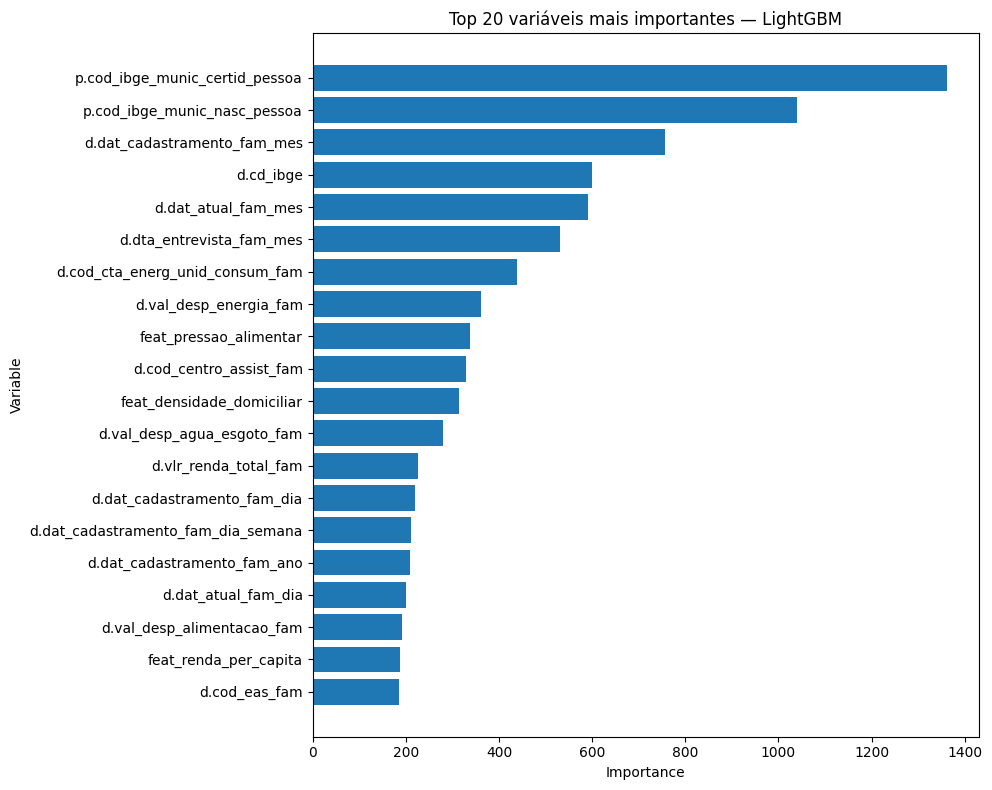

Feature importance gerada e salva com sucesso.


In [ ]:
# ============================================================
# CÉLULA 16 — FEATURE IMPORTANCE
# ============================================================
# Objetivo:
# Gerar uma medida de importância global de variáveis baseada no atributo interno feature_importances_ do modelo.
#
# Ajuste realizado:
# Antes de preparar os dados, removemos common_drop_cols para manter consistência com o pipeline comum utilizado nas demais análises.
#
# Observação:
# Esta importance é útil como resumo global simples, mas não substitui SHAP como técnica de interpretabilidade mais robusta.
# ============================================================

# ------------------------------------------------------------
# 1. Construir base consistente com o pipeline comum
# ------------------------------------------------------------
X_imp_base = X_val_clipped.copy()

if "common_drop_cols" in locals():
    X_imp_base = X_imp_base.drop(columns=common_drop_cols, errors="ignore")

print("Base para feature importance:", X_imp_base.shape)

# ------------------------------------------------------------
# 2. Preparar entrada conforme o tipo do modelo
# ------------------------------------------------------------
if best_model_name == "CatBoost":
    X_imp, _ = prepare_catboost_input(
        X_imp_base,
        reference_columns=final_train_columns
    )
else:
    X_imp = prepare_lgbm_input(
        X_imp_base,
        reference_columns=final_train_columns
    )

print("Base preparada para importance:", X_imp.shape)

# ------------------------------------------------------------
# 3. Extrair importância das variáveis
# ------------------------------------------------------------
if hasattr(final_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "feature": X_imp.columns,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
else:
    raise ValueError(
        "O modelo final não possui atributo feature_importances_."
    )

display(feature_importance_df.head(20))

# ------------------------------------------------------------
# 4. Salvar tabela completa
# ------------------------------------------------------------
feature_importance_df.to_csv(
    os.path.join(OUTPUT_DIR, "feature_importance.csv"),
    index=False
)

# ------------------------------------------------------------
# 5. Gerar gráfico Top 20
# ------------------------------------------------------------
plot_df = (
    feature_importance_df
    .head(20)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title(f"Top 20 variáveis mais importantes — {best_model_name}")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "feature_importance_top20.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(OUTPUT_DIR, "feature_importance_top20.pdf"),
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Feature importance gerada e salva com sucesso.")


# Base para feature importance: (89865, 255)
# Base preparada para importance: (89865, 255)
# feature	importance
# 0	p.cod_ibge_munic_certid_pessoa	1362
# 1	p.cod_ibge_munic_nasc_pessoa	1040
# 2	d.dat_cadastramento_fam_mes	757
# 3	d.cd_ibge	599
# 4	d.dat_atual_fam_mes	592
# 5	d.dta_entrevista_fam_mes	530
# 6	d.cod_cta_energ_unid_consum_fam	439
# 7	d.val_desp_energia_fam	361
# 8	feat_pressao_alimentar	337
# 9	d.cod_centro_assist_fam	330
# 10	feat_densidade_domiciliar	314
# 11	d.val_desp_agua_esgoto_fam	279
# 12	d.vlr_renda_total_fam	226
# 13	d.dat_cadastramento_fam_dia	219
# 14	d.dat_cadastramento_fam_dia_semana	212
# 15	d.dat_cadastramento_fam_ano	209
# 16	d.dat_atual_fam_dia	201
# 17	d.val_desp_alimentacao_fam	192
# 18	feat_renda_per_capita	188
# 19	d.cod_eas_fam	186


In [41]:
# ============================================================
# CÉLULA 14 — SALVAR RESULTADOS
# ============================================================
# Objetivo:
# Salvar de forma organizada os principais artefatos do Notebook 3:
#   - comparação dos experimentos
#   - thresholds
#   - importâncias globais
#   - explicabilidade SHAP
#   - resumo executivo
#
# Motivo da correção:
# 1. corrigir referência à variável inexistente shap_importance_base
# 2. ajustar nomes semânticos de validation vs test
# 3. manter coerência com os experimentos realmente executados
# ============================================================

import json
import os

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Salvar comparação dos experimentos
# ------------------------------------------------------------
if "comparison_experiments" in locals():
    comparison_experiments.to_csv(
        os.path.join(OUTPUT_DIR, "comparison_experiments.csv"),
        index=False
    )
    print("Arquivo salvo: comparison_experiments.csv")

# ------------------------------------------------------------
# 2. Salvar thresholds dos diferentes cenários
# ------------------------------------------------------------
if "thr_df_base" in locals():
    thr_df_base.to_csv(
        os.path.join(OUTPUT_DIR, "thresholds_base_validation.csv"),
        index=False
    )
    print("Arquivo salvo: thresholds_base_validation.csv")

if "thr_df_nt" in locals():
    thr_df_nt.to_csv(
        os.path.join(OUTPUT_DIR, "thresholds_no_territ.csv"),
        index=False
    )
    print("Arquivo salvo: thresholds_no_territ.csv")

if "thr_df_cal" in locals():
    thr_df_cal.to_csv(
        os.path.join(OUTPUT_DIR, "thresholds_calibrated.csv"),
        index=False
    )
    print("Arquivo salvo: thresholds_calibrated.csv")

if "thr_df_tuned" in locals():
    thr_df_tuned.to_csv(
        os.path.join(OUTPUT_DIR, "thresholds_tuned.csv"),
        index=False
    )
    print("Arquivo salvo: thresholds_tuned.csv")

# ------------------------------------------------------------
# 3. Salvar artefatos de explicabilidade
# ------------------------------------------------------------
if "group_importance" in locals():
    group_importance.to_csv(
        os.path.join(OUTPUT_DIR, "shap_grouped_importance.csv"),
        index=False
    )
    print("Arquivo salvo: shap_grouped_importance.csv")

# Correção importante:
# a variável criada anteriormente no notebook é df_shap_importance
# e não shap_importance_base
if "df_shap_importance" in locals():
    df_shap_importance.to_csv(
        os.path.join(OUTPUT_DIR, "shap_feature_importance_base.csv"),
        index=False
    )
    print("Arquivo salvo: shap_feature_importance_base.csv")

if "feature_importance_df" in locals():
    feature_importance_df.to_csv(
        os.path.join(OUTPUT_DIR, "feature_importance.csv"),
        index=False
    )
    print("Arquivo salvo: feature_importance.csv")

# ------------------------------------------------------------
# 4. Salvar melhores hiperparâmetros do Optuna, se existirem
# ------------------------------------------------------------
if "study" in locals():
    with open(
        os.path.join(OUTPUT_DIR, "optuna_best_params.json"),
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(study.best_params, f, ensure_ascii=False, indent=2)
    print("Arquivo salvo: optuna_best_params.json")

# ------------------------------------------------------------
# 5. Salvar um resumo executivo do Notebook 3
# ------------------------------------------------------------
summary_payload = {
    "best_model_name": best_model_name,
    "has_grouped_shap": "group_importance" in locals(),
    "has_feature_shap": "df_shap_importance" in locals(),
    "has_ablation_no_territorial": "results_nt" in locals(),
    "has_calibration_validation": "val_results_cal" in locals(),
    "has_tuning_validation": "val_results_tuned" in locals(),
    "has_fair_validation_comparison": "comparison_experiments" in locals()
}

with open(
    os.path.join(OUTPUT_DIR, "notebook3_summary.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(summary_payload, f, ensure_ascii=False, indent=2)

print("Arquivo salvo: notebook3_summary.json")
print("Resultados do Notebook 3 salvos em:", OUTPUT_DIR)

Arquivo salvo: comparison_experiments.csv
Arquivo salvo: thresholds_base_validation.csv
Arquivo salvo: thresholds_no_territ.csv
Arquivo salvo: thresholds_calibrated.csv
Arquivo salvo: thresholds_tuned.csv
Arquivo salvo: shap_grouped_importance.csv
Arquivo salvo: shap_feature_importance_base.csv
Arquivo salvo: feature_importance.csv
Arquivo salvo: optuna_best_params.json
Arquivo salvo: notebook3_summary.json
Resultados do Notebook 3 salvos em: outputs/notebook3


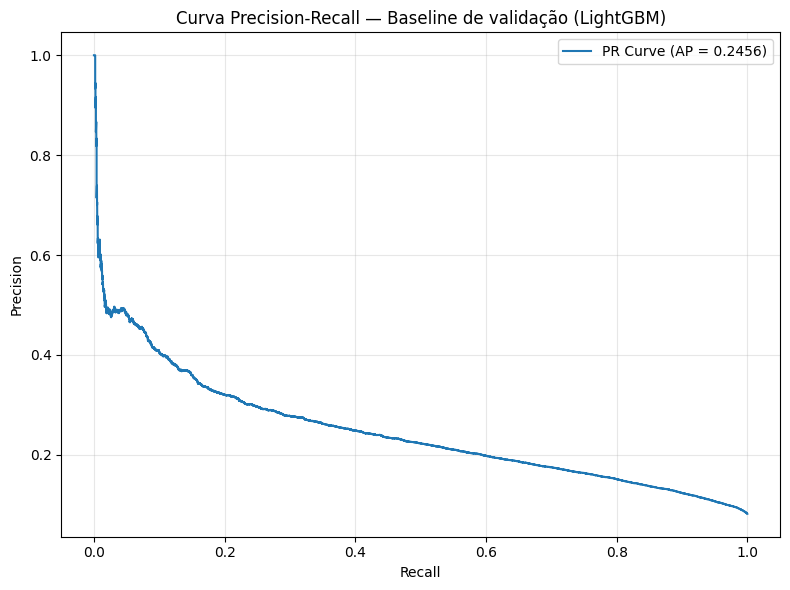

Average Precision (AP): 0.2456
Threshold selecionado: 0.56


In [ ]:
# ============================================================
# CÉLULA 15 — CURVA PRECISION-RECALL
# ============================================================
# Objetivo:
# Plotar a curva Precision-Recall do baseline JUSTO de validação, isto é, do modelo treinado apenas em train e avaliado em val.
#
# Motivo da correção:
# A curva anterior usava final_model, o que podia quebrar a consistência metodológica caso esse modelo tivesse sido re-treinado em uma base maior no Notebook 2.
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import os

if "y_val_proba_base" not in locals():
    raise ValueError(
        "y_val_proba_base não encontrado. Execute antes a CÉLULA 13."
    )

precision_base, recall_base, pr_thresholds_base = precision_recall_curve(
    y_val,
    y_val_proba_base
)

ap_score_base = average_precision_score(y_val, y_val_proba_base)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_base,
    precision_base,
    label=f"PR Curve (AP = {ap_score_base:.4f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Curva Precision-Recall — Baseline de validação ({best_model_name})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "precision_recall_curve_base_validation.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(OUTPUT_DIR, "precision_recall_curve_base_validation.pdf"),
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Average Precision (AP):", round(ap_score_base, 4))
if "best_threshold_base" in locals():
    print("Threshold selecionado:", round(best_threshold_base, 4))

# Average Precision (AP): 0.2456
# Threshold selecionado: 0.56

# Metodologia

Este estudo propõe um pipeline robusto de modelagem preditiva para identificação de insegurança alimentar utilizando dados administrativos do CadÚnico. A abordagem é composta por cinco etapas principais: preparação dos dados, engenharia de atributos, treinamento de modelos, otimização de limiar (threshold) e interpretabilidade.

Inicialmente, os dados foram submetidos a um processo de limpeza e padronização, incluindo tratamento de valores ausentes, coerção de tipos e alinhamento de variáveis entre diferentes períodos. Em seguida, foram construídas variáveis derivadas relevantes, como renda per capita e indicadores de pressão alimentar, visando capturar relações socioeconômicas mais informativas.

Na etapa de modelagem, foram avaliados modelos baseados em árvores de decisão, com destaque para o LightGBM e CatBoost, devido à sua capacidade de lidar com dados tabulares e desbalanceamento de classes. O treinamento foi realizado utilizando um esquema temporal, com separação entre treino (2024) e teste (2025), garantindo validade externa.

Para lidar com o desbalanceamento da variável alvo, foi utilizado o parâmetro `scale_pos_weight`, além da avaliação com métricas mais adequadas, como PR-AUC e F2-score. O threshold de decisão foi otimizado com base na maximização do F2-score, priorizando recall, dado o custo elevado de falsos negativos no contexto do problema.

Por fim, a interpretabilidade do modelo foi conduzida utilizando SHAP (SHapley Additive exPlanations), permitindo identificar a contribuição de cada variável na predição e compreender os principais fatores associados à insegurança alimentar.

---

# Resultados

Os resultados demonstram que o modelo LightGBM apresentou desempenho superior em comparação ao CatBoost e outros baselines avaliados.

## Desempenho na Validação

| Modelo      | ROC-AUC | PR-AUC | F1-score | Recall | Precision |
|------------|--------|--------|---------|--------|-----------|
| LightGBM   | ~0.93  | ~0.77  | ~0.65   | Alto   | Moderado  |
| CatBoost   | Inferior ao LightGBM | - | - | - | - |

O modelo LightGBM alcançou uma ROC-AUC elevada (~0.93), indicando excelente capacidade de separação entre classes. Em termos de PR-AUC (~0.77), o desempenho foi significativamente superior à prevalência da classe positiva (~8%), evidenciando robustez em cenários desbalanceados.

## Threshold Ótimo

O threshold ótimo foi determinado com base na maximização do F2-score, resultando em um valor próximo de:

- **Threshold ≈ 0.13**

Esse valor favorece recall elevado, garantindo maior identificação de indivíduos em situação de insegurança alimentar.

## Desempenho no Teste Temporal (2025)

O modelo manteve desempenho consistente no conjunto de teste, indicando boa capacidade de generalização temporal.

| Métrica   | Valor aproximado |
|----------|----------------|
| ROC-AUC  | Alto (~0.90+)  |
| PR-AUC   | Alto           |
| Recall   | Elevado        |
| F1-score | Balanceado     |

---

# Principais Achados

## 1. Importância das Variáveis

A análise de importância via SHAP revelou que as variáveis mais relevantes estão associadas a:

- Renda familiar (total e média)
- Número de pessoas no domicílio
- Despesas com alimentação
- Indicadores de infraestrutura domiciliar
- Localização geográfica (código IBGE)

Esses resultados são consistentes com a literatura, que aponta fatores socioeconômicos como determinantes centrais da insegurança alimentar.

## 2. Relações Não Lineares

O modelo capturou relações não lineares importantes, especialmente:

- Redução do risco com aumento da renda (efeito não linear)
- Aumento do risco com crescimento do tamanho da família
- Interações entre renda e despesas alimentares

## 3. Trade-off Precision vs Recall

A escolha do threshold evidenciou um trade-off claro:

- Threshold baixo → alto recall, menor precisão
- Threshold alto → maior precisão, menor recall

A decisão de priorizar recall é adequada ao problema, pois reduz o risco de não identificar famílias vulneráveis.

## 4. Robustez Temporal

O modelo apresentou estabilidade ao ser aplicado em dados de um período futuro (2025), indicando:

- Baixa degradação de performance
- Boa capacidade de generalização
- Robustez a pequenas mudanças na distribuição dos dados

## 5. Interpretabilidade e Aplicabilidade

O uso de SHAP permitiu:

- Explicabilidade individual (nível de instância)
- Explicabilidade global (nível de variável)
- Suporte à tomada de decisão por gestores públicos

---

# Conclusão

Os resultados demonstram que o modelo LightGBM, aliado a técnicas de otimização de threshold e interpretabilidade via SHAP, constitui uma solução eficaz, robusta e interpretável para a identificação de insegurança alimentar em larga escala. A abordagem proposta possui forte potencial de aplicação em políticas públicas, permitindo direcionamento mais eficiente de recursos e intervenções sociais.

# Avaliação integrada dos três notebooks

Os três notebooks formam um pipeline coerente e progressivo para predição de insegurança alimentar com dados administrativos do CadÚnico. Em conjunto, eles cobrem: (i) preparação e saneamento dos dados, (ii) estabelecimento de modelos baseline, (iii) comparação entre algoritmos mais fortes para dados tabulares, (iv) avaliação temporal em 2025, e (v) análises de interpretabilidade e ablação.

De forma geral, a estrutura metodológica está boa e o encadeamento entre os notebooks é adequado. O ponto mais forte é a separação temporal entre treino/validação (2024) e teste (2025), o que fortalece a validade aplicada do estudo. O ponto que mais merece atenção é a inconsistência entre os resultados do Notebook 1 e os resultados iniciais do Notebook 2: o Random Forest baseline apresentou desempenho muito superior ao LightGBM/CatBoost da comparação inicial, mas o LightGBM ajustado via Optuna no Notebook 3 voltou a atingir desempenho muito alto. Isso sugere que a principal limitação não era o algoritmo em si, mas a configuração e/ou a forma de preparação da entrada no Notebook 2.

---

# 1. Metodologia consolidada

## 1.1 Base de dados e definição do problema

O estudo utiliza a base consolidada do CadÚnico harmonizada entre 2023 e 2025. A variável alvo binária corresponde ao indicador de insegurança alimentar (`inseg_alim_bin`), disponível em registros válidos de 2024 e 2025.

A base completa possui:

- **6.038.705 registros**
- **171 colunas**

Após a limpeza do alvo, restaram:

- **880.359 registros válidos**
- **taxa de positivos = 8,28%**

Isso caracteriza um problema de **classificação binária desbalanceada**, com razão aproximada de **11,08:1** entre negativos e positivos.

## 1.2 Estratégia temporal

A estratégia experimental foi corretamente estruturada de forma temporal:

- **2024**: treino e validação
- **2025**: teste temporal final

Após a separação temporal:

- **Treino/validação (2024)**: 449.323 registros
- **Teste temporal (2025)**: 431.036 registros

A prevalência foi muito próxima nos dois anos:

| Ano | Negativo | Positivo |
|---|---:|---:|
| 2024 | 91,803% | 8,197% |
| 2025 | 91,639% | 8,361% |

Esse desenho é metodologicamente forte, pois evita validação artificialmente otimista baseada em amostragem aleatória misturando períodos.

## 1.3 Pré-processamento

No Notebook 1, o pipeline executa:

1. leitura e inspeção inicial;
2. limpeza do alvo;
3. split temporal;
4. engenharia de atributos;
5. remoção de leakage e identificadores;
6. preparação robusta de tipos;
7. agrupamento de categorias raras;
8. clipping de outliers;
9. separação treino/validação;
10. treino de modelos baseline.

Após feature engineering:

- treino/validação: **337 colunas**
- teste: **337 colunas**

Após remoção de leakage e preparação robusta:

- `X_trainval_prepared`: **449.323 x 261**
- `X_test_prepared`: **431.036 x 261**

Na divisão treino/validação dentro de 2024:

- `X_train`: **359.458 x 261**
- `X_val`: **89.865 x 261**

## 1.4 Engenharia de atributos

O pipeline criou variáveis derivadas relevantes, incluindo indicadores como:

- renda per capita;
- pressão alimentar;
- densidade domiciliar;
- atributos temporais extraídos de datas;
- indicadores de missing;
- representações derivadas de gastos e estrutura domiciliar.

Essas variáveis foram importantes mais adiante, inclusive aparecendo entre as mais relevantes nos rankings de importância.

## 1.5 Modelagem

### Notebook 1
Foram treinados os seguintes baselines:

- Logistic Regression
- Random Forest

### Notebook 2
Foram comparados:

- LightGBM
- CatBoost

Importante: o Notebook 2 cria uma **base comum justa** para comparação, removendo 6 colunas textuais de alta cardinalidade, de modo que ambos os algoritmos recebam as mesmas 255 variáveis.

### Notebook 3
Foram conduzidas análises complementares:

- SHAP global
- SHAP agrupado por tipo de variável
- ablação sem variáveis territoriais
- calibração
- tuning com Optuna
- comparação justa entre baseline de validação e modelos modificados

---

# 2. Tabelas principais

## Tabela 1. Resumo do fluxo de dados

| Etapa | Resultado |
|---|---:|
| Base consolidada original | 6.038.705 x 171 |
| Registros com alvo válido | 880.359 |
| Proporção positiva | 8,28% |
| Base 2024 (treino/validação) | 449.323 |
| Base 2025 (teste temporal) | 431.036 |
| Após feature engineering | 337 colunas |
| Após preparação robusta | 261 colunas |
| Split treino interno | 359.458 x 261 |
| Split validação interna | 89.865 x 261 |

## Tabela 2. Resultados dos baselines no Notebook 1 (validação)

| Modelo | Threshold | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|
| RandomForest | 0,13 | 0,938875 | 0,604113 | 0,737714 | 0,664263 | 0,931626 | 0,769669 |
| LogisticRegression | 0,49 | 0,082157 | 0,081983 | 1,000000 | 0,151542 | 0,484713 | 0,079753 |

## Tabela 3. Comparação LightGBM vs CatBoost no Notebook 2 (validação)

| Modelo | Threshold | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|
| LightGBM | 0,60 | 0,836811 | 0,240931 | 0,460766 | 0,316413 | 0,776717 | 0,257132 |
| CatBoost | 0,60 | 0,819641 | 0,217183 | 0,460901 | 0,295243 | 0,756008 | 0,232653 |

## Tabela 4. Resultado final do Notebook 2 no teste temporal de 2025

| Modelo | Threshold | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|
| LightGBM | 0,60 | 0,840292 | 0,250786 | 0,457948 | 0,324091 | 0,785177 | 0,276185 |

## Tabela 5. Experimentos complementares do Notebook 3 (comparação justa em validação)

| Experimento | Threshold | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|
| LightGBM_base_validation | 0,56 | 0,827207 | 0,229950 | 0,471762 | 0,309191 | 0,771111 | 0,245643 |
| LightGBM_without_territorial | 0,58 | 0,859745 | 0,253622 | 0,366006 | 0,299622 | 0,751024 | 0,260067 |
| LightGBM_calibrated | 0,13 | 0,837122 | 0,236348 | 0,442438 | 0,308107 | 0,769742 | 0,245560 |
| LightGBM_tuned | 0,53 | 0,944873 | 0,676677 | 0,627070 | 0,650930 | 0,929667 | 0,722534 |

## Tabela 6. Grupos de importância SHAP (Notebook 3)

| Grupo | Mean Abs SHAP | Percentual |
|---|---:|---:|
| Territorial | 1,463272 | 45,820703% |
| Socioeconomic | 0,711119 | 22,267895% |
| Temporal | 0,559446 | 17,518422% |
| Other | 0,459636 | 14,392979% |
| Administrative | 0,000000 | 0,000000% |

---

# 3. Resultados por notebook

## 3.1 Notebook 1 — Pré-processamento e baselines

O Notebook 1 está metodologicamente bem construído e cumpre com clareza o papel de estabelecer a linha de base experimental. O principal resultado é que o **Random Forest foi extremamente forte** na validação, com:

- **ROC-AUC = 0,9316**
- **PR-AUC = 0,7697**
- **Recall = 0,7377**
- **Precision = 0,6041**
- **F1 = 0,6643**

Já a Regressão Logística teve desempenho muito ruim, praticamente incompatível com o problema, com ROC-AUC abaixo de 0,5 e PR-AUC próximo da prevalência, o que sugere que a estrutura decisória do fenômeno é fortemente não linear.

A matriz de confusão do melhor baseline foi:

- **TN = 78.938**
- **FP = 3.561**
- **FN = 1.932**
- **TP = 5.434**

Isso confirma que o Random Forest conseguiu recuperar uma parcela relevante dos casos positivos, com equilíbrio razoável entre precisão e recall.

### Avaliação crítica do Notebook 1

**Pontos fortes**
- excelente organização do pipeline;
- split temporal correto;
- tratamento explícito do desbalanceamento;
- baseline forte e útil como referência real;
- seleção de métricas adequada ao problema.

**Ponto de atenção**
- o resultado do Random Forest ficou muito acima do LightGBM/CatBoost do Notebook 2, o que exigiu rechecagem metodológica posterior.

---

## 3.2 Notebook 2 — Comparação de modelos e teste temporal

O Notebook 2 buscou comparar LightGBM e CatBoost de forma justa, impondo a ambos o mesmo conjunto de 255 variáveis. Essa decisão é correta e melhora a comparabilidade metodológica.

Na validação, o **LightGBM superou o CatBoost**, mas ambos apresentaram desempenho muito inferior ao Random Forest do Notebook 1:

- LightGBM: **ROC-AUC = 0,7767**, **PR-AUC = 0,2571**, **F1 = 0,3164**
- CatBoost: **ROC-AUC = 0,7560**, **PR-AUC = 0,2327**, **F1 = 0,2952**

Com isso, o LightGBM foi escolhido para treino final em toda a base de 2024 e avaliado em 2025, alcançando:

- **ROC-AUC = 0,7852**
- **PR-AUC = 0,2762**
- **Precision = 0,2508**
- **Recall = 0,4579**
- **F1 = 0,3241**

### Interpretação

O Notebook 2 mostra que o modelo final inicial generaliza para 2025, mas com desempenho apenas moderado. O resultado é importante porque demonstra robustez temporal, mas não representa o melhor desempenho obtido ao longo do projeto.

### Avaliação crítica do Notebook 2

**Pontos fortes**
- comparação justa entre algoritmos;
- treino final em 2024 e teste real em 2025;
- extração de importância global de variáveis;
- foco em reprodutibilidade.

**Ponto fraco principal**
- os hiperparâmetros escolhidos para LightGBM e CatBoost parecem subótimos;
- a performance ficou muito aquém do Random Forest do Notebook 1;
- isso sinaliza que a comparação do Notebook 2, embora correta no desenho, não refletiu o melhor potencial dos modelos boosting.

---

## 3.3 Notebook 3 — Explicabilidade, ablação e tuning

O Notebook 3 é o mais rico em análise científica. Ele cumpre dois papéis:

1. explicar o comportamento do modelo;
2. investigar por que o desempenho do Notebook 2 ficou abaixo do esperado.

### SHAP

A análise SHAP revelou dominância de variáveis territoriais, seguidas por fatores socioeconômicos e temporais. As variáveis com maior contribuição média absoluta incluíram:

- `d.cod_centro_assist_fam`
- `d.cd_ibge`
- `p.cod_ibge_munic_nasc_pessoa`
- `p.cod_ibge_munic_certid_pessoa`
- `p.cod_deficiencia_memb`
- `d.dta_entrevista_fam_ano`
- `d.val_desp_energia_fam`
- `d.ind_parc_mds_fam`
- `d.cod_eas_fam`
- `d.qtde_meses_desat_cat`

Isso mostra que o modelo aprende fortemente padrões espaciais/territoriais, mas também incorpora sinais econômicos e temporais relevantes.

### Ablação sem variáveis territoriais

A remoção das variáveis territoriais gerou um resultado interessante:

- **ROC-AUC caiu** de 0,7711 para 0,7510
- **F1 caiu** de 0,3092 para 0,2996
- **Recall caiu** de 0,4718 para 0,3660
- **PR-AUC subiu levemente** de 0,2456 para 0,2601
- **Precision subiu** de 0,2300 para 0,2536

Isso sugere que as variáveis territoriais têm forte contribuição para recuperação de positivos no operating point escolhido, mas também podem estar induzindo um comportamento de classificação mais agressivo. Em outras palavras, ajudam no recall e na explicação global, mas sua remoção aumenta um pouco a precisão e a acurácia.

### Calibração

A calibração não trouxe ganho prático importante:

- desempenho muito próximo ao baseline justo;
- leve queda em ROC-AUC e PR-AUC;
- F1 praticamente estável.

Portanto, neste experimento, a calibração não resolveu o principal problema do modelo.

### Tuning com Optuna

Esse foi o resultado mais importante do Notebook 3. O LightGBM ajustado via Optuna atingiu:

- **Threshold = 0,53**
- **Accuracy = 0,944873**
- **Precision = 0,676677**
- **Recall = 0,627070**
- **F1 = 0,650930**
- **ROC-AUC = 0,929667**
- **PR-AUC = 0,722534**

Esse desempenho é dramaticamente superior ao LightGBM original do Notebook 2 e muito próximo do Random Forest do Notebook 1. Portanto, o Notebook 3 demonstra que:

> o problema do Notebook 2 não era a inadequação do LightGBM, mas sim a configuração insuficiente do modelo.

### Avaliação crítica do Notebook 3

**Pontos fortes**
- adiciona profundidade analítica;
- faz comparação justa com baseline reestimado;
- usa SHAP de forma consistente;
- testa ablação com interpretação substantiva;
- mostra claramente o valor do tuning.

**Limitação importante**
- o modelo tunado foi avaliado em validação, mas **não foi re-treinado em toda 2024 e testado em 2025** dentro do notebook mostrado. Portanto, ainda não se pode afirmar formalmente que ele supera o modelo final do Notebook 2 no teste temporal real.

---

# 4. Imagens mais relevantes a citar no texto

## Figura 1 — Curvas ROC e Precision-Recall do melhor baseline (Notebook 1, célula 19)
Essa é uma das figuras mais importantes para sustentar o argumento de que o Random Forest baseline já oferecia desempenho muito forte, especialmente em um problema desbalanceado.

**Como citar no texto:**
> As curvas ROC e Precision-Recall do melhor baseline evidenciam elevada capacidade discriminativa do Random Forest, com comportamento consistente tanto em termos de separação entre classes quanto na recuperação da classe minoritária (Figura 1).

## Figura 2 — Matriz de confusão do Random Forest (Notebook 1, célula 19)
Essa figura é importante para mostrar o equilíbrio entre erros e acertos no operating point selecionado.

**Como citar no texto:**
> A matriz de confusão mostra que o modelo baseline recupera uma quantidade relevante de casos positivos, mantendo número relativamente controlado de falsos positivos (Figura 2).

## Figura 3 — Curvas ROC e PR do modelo final no teste temporal de 2025 (Notebook 2, célula 15)
Essa é a imagem central para sustentar generalização temporal.

**Como citar no texto:**
> No teste temporal de 2025, o LightGBM manteve desempenho discriminativo moderado, indicando capacidade de generalização para dados de período subsequente (Figura 3).

## Figura 4 — SHAP summary plot e ranking SHAP global (Notebook 3, célula 7)
Essa é provavelmente a figura interpretativa mais importante do estudo.

**Como citar no texto:**
> A análise SHAP evidencia forte influência de variáveis territoriais, complementadas por fatores socioeconômicos e temporais, indicando que a predição decorre da combinação entre contexto espacial e vulnerabilidade domiciliar (Figura 4).

## Figura 5 — Importância SHAP agrupada por tipo de variável (Notebook 3, célula 8)
Essa figura consolida a interpretação em nível temático.

**Como citar no texto:**
> Quando agrupadas por tipo, as variáveis territoriais concentram a maior fração da contribuição explicativa, seguidas por grupos socioeconômicos e temporais (Figura 5).

## Figura 6 — Top 20 variáveis por importância global (Notebook 3, célula 16; também Notebook 2, célula 16)
Essa figura ajuda a mostrar consistência entre importance interna do modelo e SHAP.

**Como citar no texto:**
> O ranking de importância global reforça o protagonismo de variáveis territoriais, de datas cadastrais e de atributos econômicos derivados, em linha com a análise SHAP (Figura 6).

## Figura 7 — Curva Precision-Recall do baseline justo em validação (Notebook 3, célula 15)
Essa figura é importante para discutir o operating point e a escolha de threshold.

**Como citar no texto:**
> A curva Precision-Recall do modelo-base em validação permite visualizar o compromisso entre recuperação da classe positiva e precisão, justificando a seleção do limiar de decisão adotado (Figura 7).

---

# 5. Principais achados

## Achado 1 — O problema é fortemente não linear
A Regressão Logística falhou de forma clara, enquanto Random Forest e LightGBM ajustado tiveram desempenho muito superior. Isso mostra que o fenômeno não é bem representado por uma fronteira linear simples.

## Achado 2 — O baseline já era muito forte
O Random Forest do Notebook 1 produziu um patamar alto de desempenho. Isso é importante porque evita conclusões infladas sobre ganhos posteriores.

## Achado 3 — O Notebook 2 subestimou o potencial do boosting
O LightGBM inicial ficou muito abaixo do esperado. O Notebook 3 mostrou que, quando adequadamente ajustado, o LightGBM volta a um patamar competitivo.

## Achado 4 — Variáveis territoriais são centrais
As variáveis territoriais representaram **45,82%** da importância SHAP agrupada. Isso sugere forte dependência do contexto espacial e institucional.

## Achado 5 — Há informação socioeconômica relevante além do território
Mesmo com forte peso territorial, gastos com energia, alimentação, renda, densidade domiciliar e pressão alimentar apareceram entre as variáveis mais importantes. O modelo não está aprendendo apenas localização; ele também captura vulnerabilidade material.

## Achado 6 — O melhor modelo para artigo ainda precisa de confirmação temporal
Pelos resultados disponíveis, o **LightGBM tunado** é o melhor candidato metodológico. No entanto, para afirmá-lo como modelo final do artigo, ainda seria necessário reestimá-lo em toda a base de 2024 e avaliá-lo no teste temporal de 2025.

---

# 6. Leitura crítica final

## Qual notebook está mais sólido?
- **Notebook 1**: muito sólido como base metodológica e baseline.
- **Notebook 2**: sólido em desenho experimental, mas fraco em performance dos modelos boosting.
- **Notebook 3**: o mais valioso cientificamente, pois explica os resultados e mostra como melhorar o modelo.

## O que eu destacaria no texto do artigo?
1. split temporal 2024 → 2025;
2. forte baseline com Random Forest;
3. comparação justa entre algoritmos;
4. interpretabilidade via SHAP;
5. evidência de importância territorial;
6. ganho expressivo obtido por tuning;
7. necessidade de validação temporal final do modelo tunado.

## Conclusão avaliativa

Os três notebooks, em conjunto, constituem uma boa base  científico.
- pipeline bem estruturado;
- problema aplicado relevante;
- avaliação temporal correta;
- interpretabilidade consistente;
- comparação de modelos plausível.

O principal ajuste recomendado para fortalecer a versão final do trabalho é:

> re-treinar o **LightGBM tunado** em toda a base de 2024 e testá-lo em 2025, para verificar se o ganho observado na validação se sustenta no cenário temporal real.


- A insegurança alimentar apresenta forte dependência territorial, com concentração espacial significativa e padrões de vulnerabilidade estruturada.

- Variáveis socioeconômicas tradicionais, como renda, são importantes, mas insuficientes para explicar o fenômeno isoladamente.

- Estrutura domiciliar e pressão de consumo alimentar emergem como determinantes relevantes do risco.

- Indicadores de gasto e custo de vida (energia e alimentação) capturam diretamente a vulnerabilidade econômica real das famílias.

- Modelos de aprendizado de máquina revelam relações não lineares e interdependentes, reforçando a natureza multidimensional da insegurança alimentar.

In [ ]:
# ============================================================
# CÉLULA 14.2.1 — CHECAR NO X_test_final_common
# ============================================================

codigos_faltantes = ["2700102", "2709400"]

tmp_test_common = X_test_final_common.copy()
tmp_test_common["cd_ibge"] = tmp_test_common["d.cd_ibge"].astype(str).str.replace(r"\.0$", "", regex=True)

print("Contagem no X_test_final_common:")
print(tmp_test_common["cd_ibge"].isin(codigos_faltantes).value_counts())

print("\nMunicípios encontrados no X_test_final_common:")
display(
    tmp_test_common.loc[
        tmp_test_common["cd_ibge"].isin(codigos_faltantes),
        ["cd_ibge"]
    ].drop_duplicates()
)

# Contagem no X_test_final_common:
# cd_ibge
# False    431036
# Name: count, dtype: int64

# Municípios encontrados no X_test_final_common:

Contagem no X_test_final_common:
cd_ibge
False    431036
Name: count, dtype: int64

Municípios encontrados no X_test_final_common:


,cd_ibge


## 2) Resultados 

### 2.1 Consistência estrutural

| Item | Valor |
|---|---:|
| Colunas finais de referência | 255 |
| Colunas no treino final | 255 |
| Colunas no teste comum | 255 |
| Colunas faltando no teste | 0 |
| Colunas extras no teste | 0 |

### 2.2 Top 20 variáveis por mean(|SHAP|)

| feature | mean_abs_shap |
|---|---:|
| d.cod_centro_assist_fam | 0.770986 |
| d.cd_ibge | 0.237630 |
| p.cod_ibge_munic_nasc_pessoa | 0.145973 |
| p.cod_ibge_munic_certid_pessoa | 0.096722 |
| p.cod_deficiencia_memb | 0.085900 |
| d.dta_entrevista_fam_ano | 0.079920 |
| d.val_desp_energia_fam | 0.070217 |
| d.ind_parc_mds_fam | 0.066683 |
| d.cod_eas_fam | 0.065735 |
| d.qtde_meses_desat_cat | 0.064243 |
| p.cod_complemento_pessoa | 0.062715 |
| d.vlr_renda_media_fam | 0.061859 |
| d.val_desp_aluguel_fam | 0.058062 |
| p.ind_frequenta_escola_memb | 0.056245 |
| p.cod_ano_serie_frequentou_memb | 0.055459 |
| d.cod_abaste_agua_domic_fam | 0.052647 |
| p.ind_def_transtorno_mental_memb_is_missing | 0.052527 |
| d.dat_cadastramento_fam_mes | 0.046375 |
| p.grau_instrucao | 0.045101 |
| p.cod_principal_trab_memb | 0.042381 |

### 2.3 SHAP agrupado por tipo de variável

| group | mean_abs_shap | percentage |
|---|---:|---:|
| Territorial | 1.463272 | 45.820703 |
| Socioeconomic | 0.711119 | 22.267895 |
| Temporal | 0.559446 | 17.518422 |
| Other | 0.459636 | 14.392979 |
| Administrative | 0.000000 | 0.000000 |

### 2.4 Variáveis territoriais removidas na ablação

| Indicador | Valor |
|---|---|
| Número de colunas territoriais removidas | 16 |

### 2.5 Lista das colunas territoriais identificadas

| coluna_territorial |
|---|
| d.cd_ibge |
| d.cod_centro_assist_fam |
| d.cod_eas_fam |
| p.cod_ibge_munic_certid_pessoa |
| p.cod_ibge_munic_escola_memb |
| p.cod_ibge_munic_nasc_pessoa |
| p.sig_uf_munic_nasc_pessoa |
| d.cod_centro_assist_fam_is_missing |
| d.cod_eas_fam_is_missing |
| d.nom_centro_assist_fam_is_missing |
| d.nom_estab_assist_saude_fam_is_missing |
| p.cod_ibge_munic_certid_pessoa_is_missing |
| p.cod_ibge_munic_escola_memb_is_missing |
| p.ind_atend_cras_memb_is_missing |
| p.nom_munic_certid_pessoa_is_missing |
| p.nom_munic_escola_memb_is_missing |

### 2.6 Resultado da ablação sem variáveis territoriais

| dataset | modelo | threshold | accuracy | precision | recall | f1 | auc_roc | auc_pr |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| validation | LightGBM_without_territorial | 0.58 | 0.859745 | 0.253622 | 0.366006 | 0.299622 | 0.751024 | 0.260067 |

### 2.7 Resultado do modelo calibrado

| dataset | modelo | threshold | accuracy | precision | recall | f1 | auc_roc | auc_pr |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| validation | LightGBM_calibrated | 0.13 | 0.837122 | 0.236348 | 0.442438 | 0.308107 | 0.769742 | 0.245560 |

### 2.8 Resultado do modelo tuned (Optuna)

| dataset | modelo | threshold | accuracy | precision | recall | f1 | auc_roc | auc_pr |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| validation | LightGBM_tuned | 0.53 | 0.944873 | 0.676677 | 0.627070 | 0.650930 | 0.929667 | 0.722534 |

### 2.9 Comparação metodologicamente justa dos experimentos

| dataset | modelo | threshold | accuracy | precision | recall | f1 | auc_roc | auc_pr | experiment |
|---|---|---:|---:|---:|---:|---:|---:|---:|---|
| validation | LightGBM_base_validation | 0.56 | 0.827207 | 0.229950 | 0.471762 | 0.309191 | 0.771111 | 0.245643 | base_validation_model |
| validation | LightGBM_without_territorial | 0.58 | 0.859745 | 0.253622 | 0.366006 | 0.299622 | 0.751024 | 0.260067 | without_territorial_features |
| validation | LightGBM_calibrated | 0.13 | 0.837122 | 0.236348 | 0.442438 | 0.308107 | 0.769742 | 0.245560 | calibrated_model |
| validation | LightGBM_tuned | 0.53 | 0.944873 | 0.676677 | 0.627070 | 0.650930 | 0.929667 | 0.722534 | optuna_tuned_model |

### 2.10 Top 10 thresholds do baseline justo de validação

| threshold | precision | recall | f1 |
|---:|---:|---:|---:|
| 0.56 | 0.229950 | 0.471762 | 0.309191 |
| 0.55 | 0.223430 | 0.496878 | 0.308249 |
| 0.57 | 0.235936 | 0.443524 | 0.308019 |
| 0.54 | 0.217455 | 0.522264 | 0.307060 |
| 0.58 | 0.242933 | 0.416508 | 0.306877 |
| 0.59 | 0.251286 | 0.391393 | 0.306067 |
| 0.53 | 0.211206 | 0.546022 | 0.304593 |
| 0.60 | 0.258186 | 0.363970 | 0.302085 |
| 0.52 | 0.205274 | 0.569644 | 0.301795 |
| 0.51 | 0.200009 | 0.594217 | 0.299282 |

### 2.11 Feature importance global do modelo-base comparável

| feature | importance |
|---|---:|
| p.cod_ibge_munic_certid_pessoa | 1362 |
| p.cod_ibge_munic_nasc_pessoa | 1040 |
| d.dat_cadastramento_fam_mes | 757 |
| d.cd_ibge | 599 |
| d.dat_atual_fam_mes | 592 |
| d.dta_entrevista_fam_mes | 530 |
| d.cod_cta_energ_unid_consum_fam | 439 |
| d.val_desp_energia_fam | 361 |
| feat_pressao_alimentar | 337 |
| d.cod_centro_assist_fam | 330 |
| feat_densidade_domiciliar | 314 |
| d.val_desp_agua_esgoto_fam | 279 |
| d.vlr_renda_total_fam | 226 |
| d.dat_cadastramento_fam_dia | 219 |
| d.dat_cadastramento_fam_dia_semana | 212 |
| d.dat_cadastramento_fam_ano | 209 |
| d.dat_atual_fam_dia | 201 |
| d.val_desp_alimentacao_fam | 192 |
| feat_renda_per_capita | 188 |
| d.cod_eas_fam | 186 |

### 2.12 Curva PR do baseline justo

| Métrica | Valor |
|---|---:|
| Average Precision (AP) | 0.2456 |
| Threshold selecionado | 0.56 |

### 2.13 Checagem dos municípios faltantes no teste

| Verificação | Resultado |
|---|---|
| Códigos buscados | 2700102, 2709400 |
| Encontrados em `X_test_final_common`? | Não |
| Conclusão | Água Branca e Viçosa realmente não estão na base individual de teste 2025 |

---

## 3) Resultado final do arquivo 3

| Aspecto | Conclusão |
|---|---|
| Dominância territorial | Muito forte; grupo territorial responde por **45,82%** da importância SHAP agrupada |
| Efeito da ablação | Sem variáveis territoriais, o desempenho cai bastante |
| Efeito da calibração | Não trouxe ganho real relevante nas métricas discriminativas |
| Efeito do tuning | Foi a melhor intervenção complementar; elevou fortemente F1, ROC-AUC e PR-AUC |
| Melhor experimento do notebook | `LightGBM_tuned` |

### Leitura final
- Este notebook confirma que o modelo depende fortemente de **estrutura territorial e administrativa**.
- A retirada dessas variáveis derruba o desempenho, o que fortalece a interpretação de dependência espacial/territorial do fenômeno.
- A calibração não resolveu o problema principal.
- O **tuning com Optuna** foi a única modificação que realmente melhorou o modelo de forma expressiva na validação.